<a href="https://colab.research.google.com/github/min0left-hub/mobis_ai_education_2026/blob/main/DL_03_C_CNN_VEHICLE_DRAG_COEF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network (CNN)

## 1. Load dataset

In [1]:
# Author : leekyoj@kaist.ac.kr

# --- 1) Download data ---
!gdown --folder https://drive.google.com/drive/folders/1G_Nc1YgwjXEAV92XX2onVTOQmgWDrnZd?usp=sharing
!unzip processed_data/data_96.zip -d ./data_96

Retrieving folder contents
Processing file 1DUrppgmBUpYJSvd4oiQtPpcXWbm8WCWS data_96.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DUrppgmBUpYJSvd4oiQtPpcXWbm8WCWS
From (redirected): https://drive.google.com/uc?id=1DUrppgmBUpYJSvd4oiQtPpcXWbm8WCWS&confirm=t&uuid=43f6b5f0-3cd3-4f9b-8bd3-d1ed1981ca65
To: /content/processed_data/data_96.zip
100% 174M/174M [00:04<00:00, 35.8MB/s]
Download completed
Archive:  processed_data/data_96.zip
  inflating: ./data_96/test_x1.npy   
  inflating: ./data_96/test_x2.npy   
  inflating: ./data_96/test_y.npy    
  inflating: ./data_96/train_x1.npy  
  inflating: ./data_96/train_x2.npy  
  inflating: ./data_96/train_y.npy   
  inflating: ./data_96/val_x1.npy    
  inflating: ./data_96/val_x2.npy    
  inflating: ./data_96/val_y.npy     


## 2. Import python libraries and define util functions

In [2]:
# --- 2) Import libraries ---
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import torch.optim as optim
import random
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error as sklearn_mse
from sklearn.metrics import mean_absolute_error, r2_score

## 3. Convert images into trainable data

In [3]:
# --- 3) Data Loading ---
SAVE_DIR = './data_96'
TRAINED_DIR = './trained_models'
OUTPUT_DIR = './output'

for d in [SAVE_DIR, TRAINED_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"Created or exists: {d}")

def load_dataset(prefix):
    x1 = np.load(os.path.join(SAVE_DIR, f"{prefix}_x1.npy"), mmap_mode='r')
    x1 = np.array(x1, copy=True)
    x2 = np.load(os.path.join(SAVE_DIR, f"{prefix}_x2.npy"), mmap_mode='r')
    x2 = np.array(x2, copy=True)
    y  = np.load(os.path.join(SAVE_DIR, f"{prefix}_y.npy"),  mmap_mode='r')
    y = np.array(y, copy=True)

    x1 = torch.from_numpy(x1).permute(0,3,1,2).float()
    x2 = torch.from_numpy(x2).permute(0,3,1,2).float()
    y  = torch.from_numpy(y).float()
    print(f"Loaded {prefix}: x1 {x1.shape}, x2 {x2.shape}, y {y.shape}")
    return x1, x2, y

x_train1, x_train2, train_y = load_dataset('train')
x_val1,   x_val2,   val_y   = load_dataset('val')
x_test1,  x_test2,  test_y  = load_dataset('test')

train_loader = DataLoader(TensorDataset(x_train1, x_train2, train_y),batch_size=1024,  sampler=RandomSampler(x_train1), pin_memory=True)
val_loader   = DataLoader(TensorDataset(x_val1,   x_val2,   val_y  ),batch_size=1024,  sampler=SequentialSampler(x_val1),pin_memory=True)
test_loader  = DataLoader(TensorDataset(x_test1,  x_test2,  test_y ),batch_size=1024,  sampler=SequentialSampler(x_test1), pin_memory=True)

Created or exists: ./data_96
Created or exists: ./trained_models
Created or exists: ./output
Loaded train: x1 torch.Size([7256, 3, 96, 96]), x2 torch.Size([7256, 3, 96, 96]), y torch.Size([7256])
Loaded val: x1 torch.Size([908, 3, 96, 96]), x2 torch.Size([908, 3, 96, 96]), y torch.Size([908])
Loaded test: x1 torch.Size([908, 3, 96, 96]), x2 torch.Size([908, 3, 96, 96]), y torch.Size([908])


In [4]:
def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


reset_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
def make_tensor_dataset(x1, x2, y):
    x1_tensor = torch.tensor(x1, dtype=torch.float32)
    x2_tensor = torch.tensor(x2, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    # 이미지가 (N, H, W, C)이면 → (N, C, H, W)
    if x1_tensor.ndim == 4 and x1_tensor.shape[-1] in [1, 3]:
        x1_tensor = x1_tensor.permute(0, 3, 1, 2)

    if x2_tensor.ndim == 4 and x2_tensor.shape[-1] in [1, 3]:
        x2_tensor = x2_tensor.permute(0, 3, 1, 2)

    # y가 (N,)이면 → (N, 1)
    if y_tensor.ndim == 1:
        y_tensor = y_tensor.view(-1, 1)

    dataset = TensorDataset(x1_tensor, x2_tensor, y_tensor)

    return dataset

In [6]:
batch_size = 128

train_dataset = make_tensor_dataset(x_train1, x_train2, train_y)
val_dataset = make_tensor_dataset(x_val1, x_val2, val_y)
test_dataset = make_tensor_dataset(x_test1, x_test2, test_y)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

/tmp/ipykernel_3983/1979677853.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x1_tensor = torch.tensor(x1, dtype=torch.float32)
/tmp/ipykernel_3983/1979677853.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x2_tensor = torch.tensor(x2, dtype=torch.float32)
/tmp/ipykernel_3983/1979677853.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tensor = torch.tensor(y, dtype=torch.float32)


## 4. Check dataset


Sample Index: 0
x1 shape: (3, 96, 96)
x2 shape: (3, 96, 96)
Label / Drag Coefficient: 0.378353


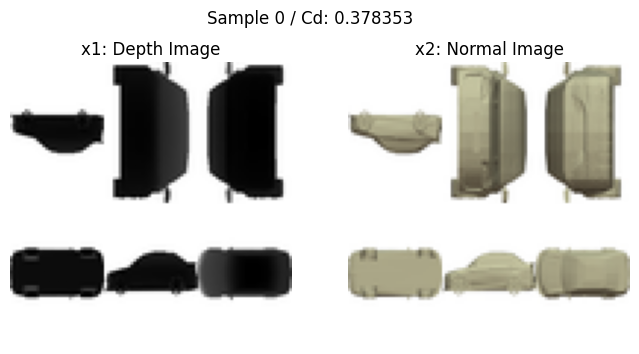

Sample Index: 1
x1 shape: (3, 96, 96)
x2 shape: (3, 96, 96)
Label / Drag Coefficient: 0.471282


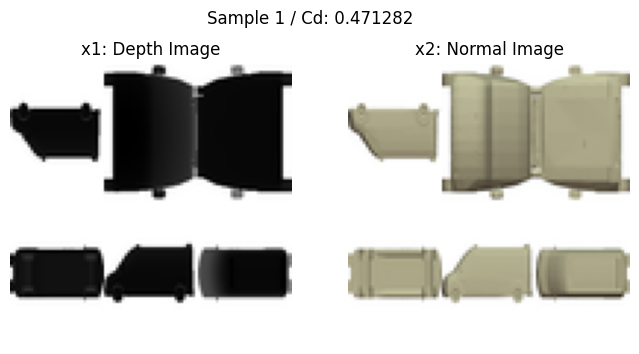

Sample Index: 2
x1 shape: (3, 96, 96)
x2 shape: (3, 96, 96)
Label / Drag Coefficient: 0.347587


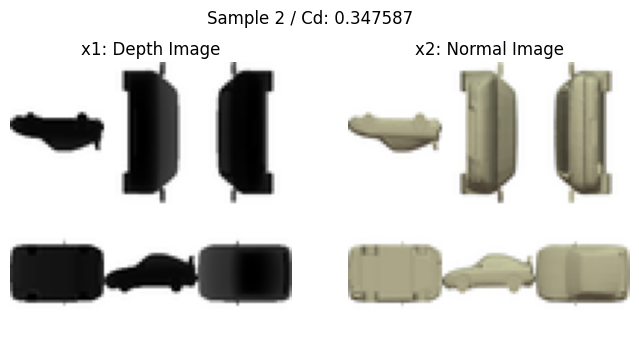

Sample Index: 3
x1 shape: (3, 96, 96)
x2 shape: (3, 96, 96)
Label / Drag Coefficient: 0.221728


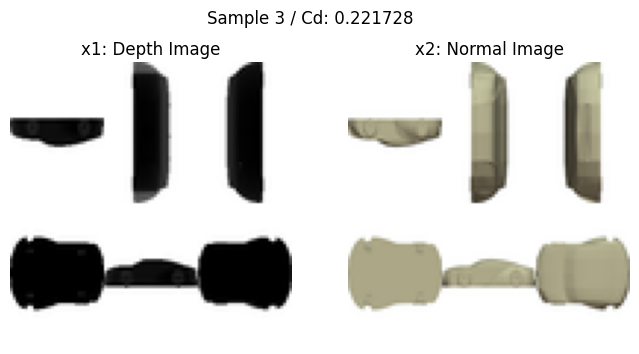

Sample Index: 4
x1 shape: (3, 96, 96)
x2 shape: (3, 96, 96)
Label / Drag Coefficient: 0.366796


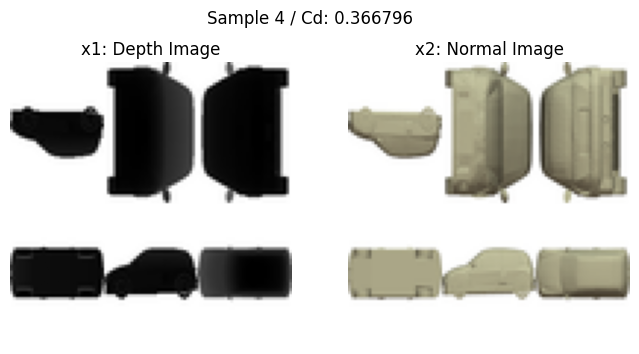

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import random

def to_img_for_show(img):
    """
    이미지가 (C, H, W)이면 (H, W, C)로 변환
    이미지가 torch tensor이면 numpy로 변환
    """
    # torch tensor인 경우 numpy로 변환
    if hasattr(img, "detach"):
        img = img.detach().cpu().numpy()

    img = np.array(img)

    # (C, H, W) -> (H, W, C)
    if img.ndim == 3 and img.shape[0] in [1, 3]:
        img = np.transpose(img, (1, 2, 0))

    # (H, W, 1)인 경우 흑백으로 보기 위해 squeeze
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img.squeeze(-1)

    # 값 범위가 0~255면 0~1로 정규화
    if img.max() > 1.0:
        img = img / 255.0

    return img


num_samples = 5
sample_indices = range(num_samples)

for idx in sample_indices:
    img1 = x_train1[idx]
    img2 = x_train2[idx]
    label = train_y[idx]

    img1_show = to_img_for_show(img1)
    img2_show = to_img_for_show(img2)

    label_value = float(np.array(label).reshape(-1)[0])

    print("=" * 60)
    print(f"Sample Index: {idx}")
    print(f"x1 shape: {np.array(img1).shape}")
    print(f"x2 shape: {np.array(img2).shape}")
    print(f"Label / Drag Coefficient: {label_value:.6f}")

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img1_show)
    plt.title("x1: Depth Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2_show)
    plt.title("x2: Normal Image")
    plt.axis("off")

    plt.suptitle(f"Sample {idx} / Cd: {label_value:.6f}")
    plt.show()


In [7]:
for x1_batch, x2_batch, y_batch in train_loader:
    print("x1_batch:", x1_batch.shape)
    print("x2_batch:", x2_batch.shape)
    print("y_batch :", y_batch.shape)
    break

x1_batch: torch.Size([128, 3, 96, 96])
x2_batch: torch.Size([128, 3, 96, 96])
y_batch : torch.Size([128, 1])


## 5. Build model architecture

In [8]:
class FusionNet_CNN(nn.Module):
    def __init__(
        self,
        conv_channels=[16, 32, 64],
        fc_units=[256, 128, 1],
        dropout_rate=0.2,
        input_channels=3,
        input_size=96
    ):
        super(FusionNet_CNN, self).__init__()

        self.feature_extractor = nn.ModuleList()

        in_channels = input_channels

        for out_channels in conv_channels:
            self.feature_extractor.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    padding=1
                )
            )
            in_channels = out_channels

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(dropout_rate)

        # feature size 자동 계산
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_size, input_size)

            x = dummy
            for conv in self.feature_extractor:
                x = conv(x)
                x = self.relu(x)
                x = self.maxpool(x)

            single_feature_size = x.view(1, -1).shape[1]

        # x1 feature + x2 feature concat이므로 2배
        fusion_feature_size = single_feature_size * 2

        self.regressor = nn.ModuleList()

        in_features = fusion_feature_size

        for out_features in fc_units:
            self.regressor.append(
                nn.Linear(in_features, out_features)
            )
            in_features = out_features

    def extract_feature(self, x):
        for conv in self.feature_extractor:
            x = conv(x)
            x = self.relu(x)
            x = self.maxpool(x)

        x = x.view(x.size(0), -1)
        return x

    def forward(self, x1, x2):
        f1 = self.extract_feature(x1)
        f2 = self.extract_feature(x2)

        combined = torch.cat([f1, f2], dim=1)

        x = combined

        for i, fc in enumerate(self.regressor):
            x = fc(x)

            # 마지막 layer에는 ReLU / Dropout 적용 X
            if i < len(self.regressor) - 1:
                x = self.relu(x)
                x = self.dropout(x)

        return x

In [9]:
config = {
    "name": "baseline_fusion_cnn",
    "conv_channels": [16, 32, 64],
    "fc_units": [256, 128, 1],
    "dropout_rate": 0.2,
    "lr": 0.001,
    "weight_decay": 1e-4,
    "batch_size": 128,
    "epochs": 50,
    "input_channels": 3,
    "input_size": 96
}

In [ ]:
# param_candidates = [
#     # 1. 기본형: 가장 먼저 돌려볼 baseline
#     {
#         "name": "baseline_fusion_cnn",
#         "conv_channels": [16, 32, 64],
#         "fc_units": [256, 128, 1],
#         "dropout_rate": 0.2,
#         "lr": 0.001,
#         "weight_decay": 1e-4,
#         "batch_size": 128,
#         "epochs": 50,
#         "input_channels": 3,
#         "input_size": 96
#     },

#     # 2. 작은 모델: 데이터가 적거나 overfitting이 심할 때
#     {
#         "name": "small_model",
#         "conv_channels": [16, 32],
#         "fc_units": [128, 1],
#         "dropout_rate": 0.1,
#         "lr": 0.001,
#         "weight_decay": 1e-5,
#         "batch_size": 128,
#         "epochs": 50,
#         "input_channels": 3,
#         "input_size": 96
#     },

#     # 3. 큰 모델: train loss / val loss 둘 다 높을 때
#     {
#         "name": "large_model",
#         "conv_channels": [32, 64, 128],
#         "fc_units": [512, 256, 1],
#         "dropout_rate": 0.2,
#         "lr": 0.0005,
#         "weight_decay": 1e-4,
#         "batch_size": 128,
#         "epochs": 50,
#         "input_channels": 3,
#         "input_size": 96
#     },

#     # 4. 과적합 방지 강화형: train은 좋은데 val/test가 안 좋을 때
#     {
#         "name": "strong_regularization",
#         "conv_channels": [16, 32, 64],
#         "fc_units": [256, 128, 1],
#         "dropout_rate": 0.4,
#         "lr": 0.001,
#         "weight_decay": 5e-4,
#         "batch_size": 128,
#         "epochs": 50,
#         "input_channels": 3,
#         "input_size": 96
#     },

#     # 5. 안정 학습형: loss가 튀거나 수렴이 불안정할 때
#     {
#         "name": "low_lr_stable",
#         "conv_channels": [16, 32, 64],
#         "fc_units": [256, 128, 1],
#         "dropout_rate": 0.2,
#         "lr": 0.0003,
#         "weight_decay": 1e-4,
#         "batch_size": 128,
#         "epochs": 50,
#         "input_channels": 3,
#         "input_size": 96
#     }
# ]

In [10]:
reset_seed(42)

model = FusionNet_CNN(
    conv_channels=config["conv_channels"],
    fc_units=config["fc_units"],
    dropout_rate=config["dropout_rate"],
    input_channels=config["input_channels"],
    input_size=config["input_size"]
).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"]
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0

print(model)

FusionNet_CNN(
  (feature_extractor): ModuleList(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (regressor): ModuleList(
    (0): Linear(in_features=18432, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 6. Train model

In [11]:
epochs = config["epochs"]

for epoch in range(epochs):
    # =========================
    # Train
    # =========================
    model.train()
    train_loss_sum = 0.0

    for x1_batch, x2_batch, y_batch in train_loader:
        x1_batch = x1_batch.to(device)
        x2_batch = x2_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(x1_batch, x2_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * x1_batch.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_losses.append(train_loss)

    # =========================
    # Validation
    # =========================
    model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for x1_batch, x2_batch, y_batch in val_loader:
            x1_batch = x1_batch.to(device)
            x2_batch = x2_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x1_batch, x2_batch)

            loss = criterion(y_pred, y_batch)

            val_loss_sum += loss.item() * x1_batch.size(0)

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_losses.append(val_loss)

    # Best model 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} "
            f"Val Loss: {val_loss:.6f}"
        )

# best validation 기준 weight 복원
model.load_state_dict(best_model_state)

print("=" * 60)
print("Training Finished")
print("Config:", config["name"])
print("Best Epoch:", best_epoch)
print("Best Val Loss:", best_val_loss)

Epoch [2/50] Train Loss: 0.006459 Val Loss: 0.003813
Epoch [4/50] Train Loss: 0.003484 Val Loss: 0.002247
Epoch [6/50] Train Loss: 0.002992 Val Loss: 0.001910
Epoch [8/50] Train Loss: 0.002576 Val Loss: 0.001797
Epoch [10/50] Train Loss: 0.002192 Val Loss: 0.002148
Epoch [12/50] Train Loss: 0.002281 Val Loss: 0.002512
Epoch [14/50] Train Loss: 0.001822 Val Loss: 0.001368
Epoch [16/50] Train Loss: 0.001770 Val Loss: 0.001362
Epoch [18/50] Train Loss: 0.001694 Val Loss: 0.001337
Epoch [20/50] Train Loss: 0.001570 Val Loss: 0.001260
Epoch [22/50] Train Loss: 0.001588 Val Loss: 0.001117
Epoch [24/50] Train Loss: 0.001392 Val Loss: 0.001154
Epoch [26/50] Train Loss: 0.001318 Val Loss: 0.001143
Epoch [28/50] Train Loss: 0.001410 Val Loss: 0.001008
Epoch [30/50] Train Loss: 0.006246 Val Loss: 0.005285
Epoch [32/50] Train Loss: 0.003661 Val Loss: 0.002940
Epoch [34/50] Train Loss: 0.002614 Val Loss: 0.002073
Epoch [36/50] Train Loss: 0.002131 Val Loss: 0.001901
Epoch [38/50] Train Loss: 0.0020

## 7. Visualize learning history

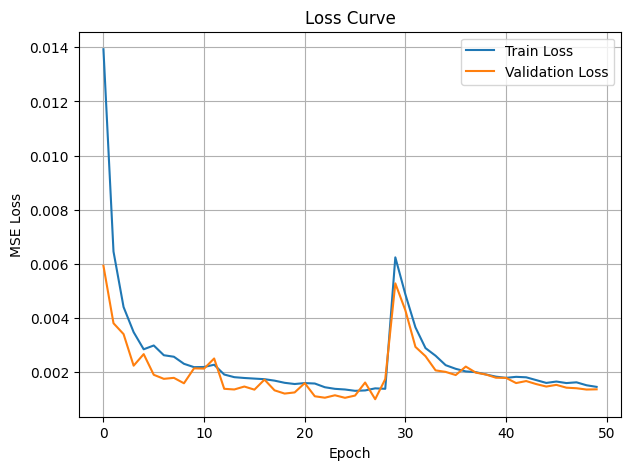

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

## 8. Evaluate model performance

In [12]:
def evaluate_model(model, data_loader, device):
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for x1_batch, x2_batch, y_batch in data_loader:
            x1_batch = x1_batch.to(device)
            x2_batch = x2_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x1_batch, x2_batch)

            y_true_list.append(y_batch.detach().cpu().numpy())
            y_pred_list.append(y_pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true_list, axis=0).reshape(-1)
    y_pred = np.concatenate(y_pred_list, axis=0).reshape(-1)

    mse = sklearn_mse(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # MAPE
    epsilon = 1e-8
    mask = np.abs(y_true) > epsilon

    if np.sum(mask) == 0:
        mape = np.nan
    else:
        mape = np.mean(
            np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
        ) * 100

    return mse, rmse, mae, mape, r2, y_true, y_pred

In [13]:
mse, rmse, mae, mape, r2, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

print("=" * 60)
print("Test Result")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.6f}")

Test Result
MSE  : 0.001060
RMSE : 0.032563
MAE  : 0.025048
MAPE : 6.19%
R2   : 0.840972


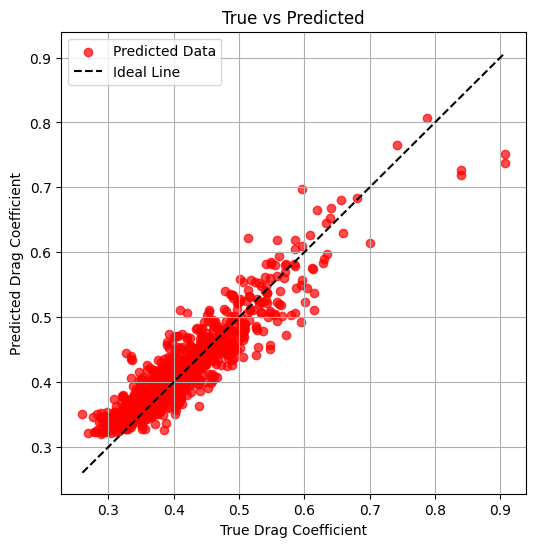

In [15]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_true,
    y_pred,
    color="red",
    alpha=0.7,
    label="Predicted Data"
)

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black",
    label="Ideal Line"
)

plt.xlabel("True Drag Coefficient")
plt.ylabel("Predicted Drag Coefficient")
plt.title("True vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

## TEST PREDICTION

In [21]:
idx = 0  # 보고 싶은 test index

In [22]:
model.eval()

sample_x1, sample_x2, sample_y = test_dataset[idx]

with torch.no_grad():
    sample_input1 = sample_x1.unsqueeze(0).to(device)
    sample_input2 = sample_x2.unsqueeze(0).to(device)

    sample_pred = model(sample_input1, sample_input2)

true_value = sample_y.detach().cpu().numpy().reshape(-1)[0]
pred_value = sample_pred.detach().cpu().numpy().reshape(-1)[0]

error = pred_value - true_value
abs_error = abs(error)

if abs(true_value) > 1e-8:
    percent_error = abs_error / abs(true_value) * 100
else:
    percent_error = None

print("Selected Index   :", idx)
print("True Cd          :", true_value)
print("Predicted Cd     :", pred_value)
print("Error            :", error)
print("Absolute Error   :", abs_error)

if percent_error is not None:
    print(f"Percent Error    : {percent_error:.2f}%")
else:
    print("Percent Error    : 계산 불가")

Selected Index   : 0
True Cd          : 0.31317088
Predicted Cd     : 0.32373238
Error            : 0.010561496
Absolute Error   : 0.010561496
Percent Error    : 3.37%


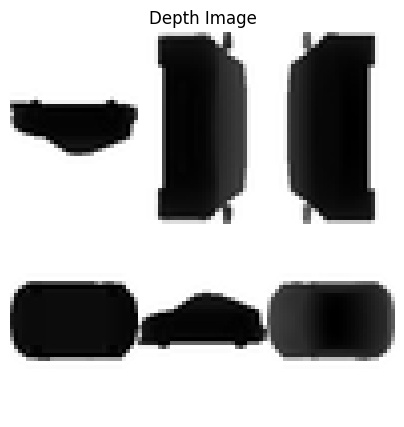

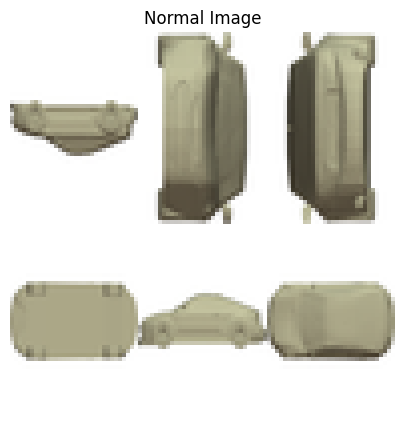

True Cd: 0.313171
Pred Cd: 0.323732


In [17]:
img1 = sample_x1.detach().cpu()
img2 = sample_x2.detach().cpu()

# (C, H, W) → (H, W, C)
img1 = img1.permute(1, 2, 0).numpy()
img2 = img2.permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(img1)
plt.title("Depth Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(img2)
plt.title("Normal Image")
plt.axis("off")
plt.show()

print(f"True Cd: {true_value:.6f}")
print(f"Pred Cd: {pred_value:.6f}")